In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=0
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

import jax
import jax.numpy as jnp
import jax.random as jr

env: CUDA_VISIBLE_DEVICES=0
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


In [2]:
from systems import Cascade, ActuatorsFault, SensorsFault, as_healty, as_faulty
from observers import KalmanFilter
from controllers import MPC
from simulator  import Simulator

In [3]:
T = 100
gamma = 0.99
sys = ActuatorsFault(SensorsFault(as_faulty(Cascade(x_dim=2, u_dim=2, y_dim=1))))

ref_y = jnp.ones((T, sys.y_dim))
ref_u = jnp.zeros((T, sys.u_dim))
Jy = 1.0 * jnp.eye(sys.y_dim)
Ju = 0.001 * jnp.eye(sys.u_dim)
Je = 0.1 * jnp.eye(sys.x_dim+sys.z_dim)

mpc = MPC(sys=as_healty(sys), Jy=Jy, Ju=Ju, horizon=10, discount=gamma)
kf = KalmanFilter(sys=as_healty(sys), Q=0.01, R=0.01)
sim = Simulator(sys=sys, mpc=mpc, kf=kf, Jy=Jy, Ju=Ju, Je=Je, ref_y=ref_y, ref_u=ref_u)

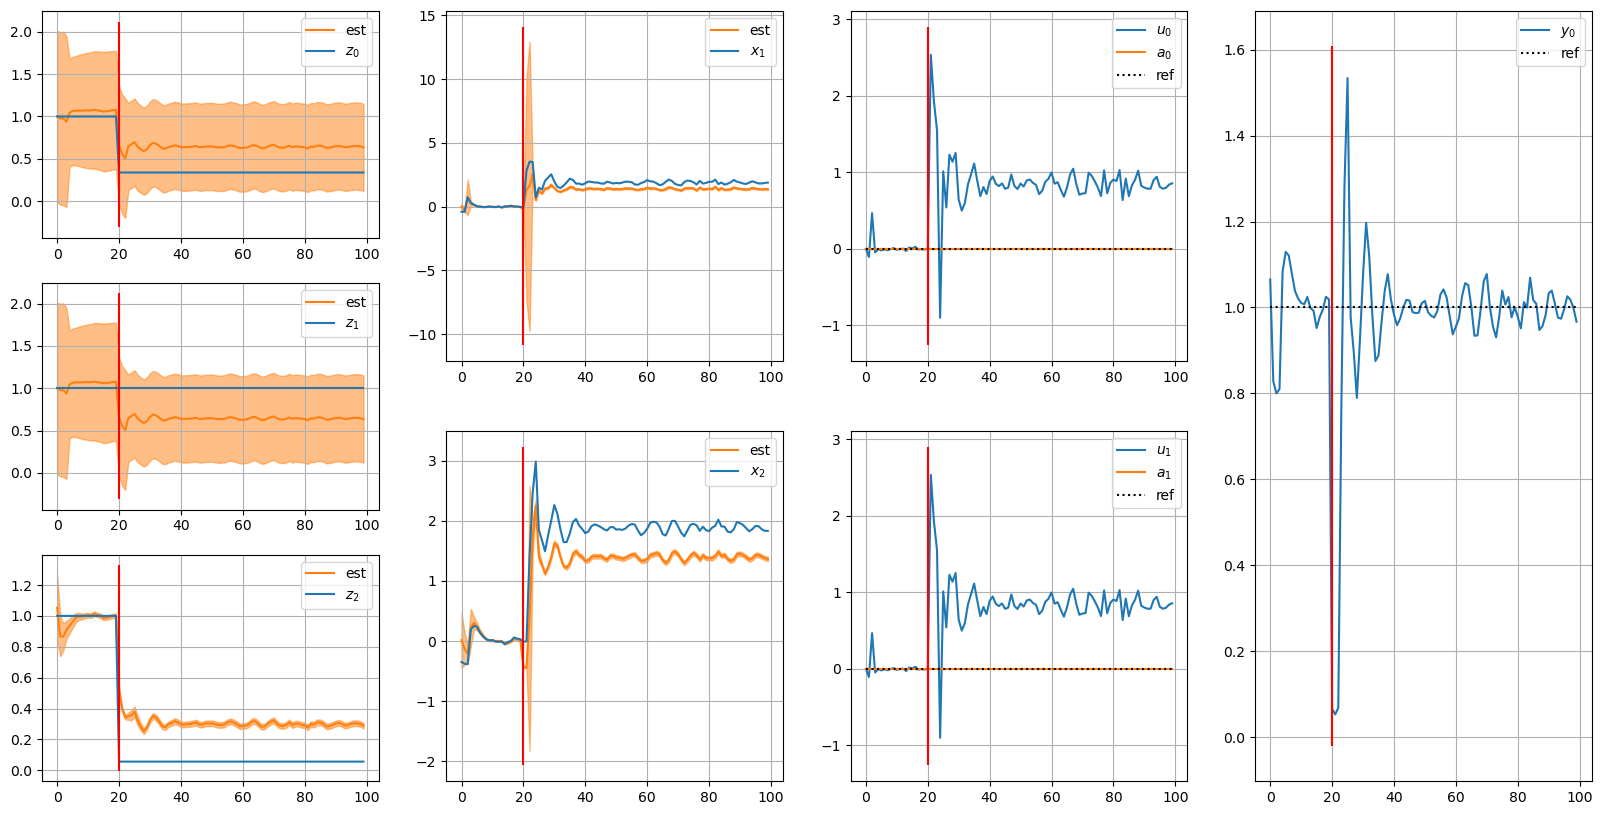

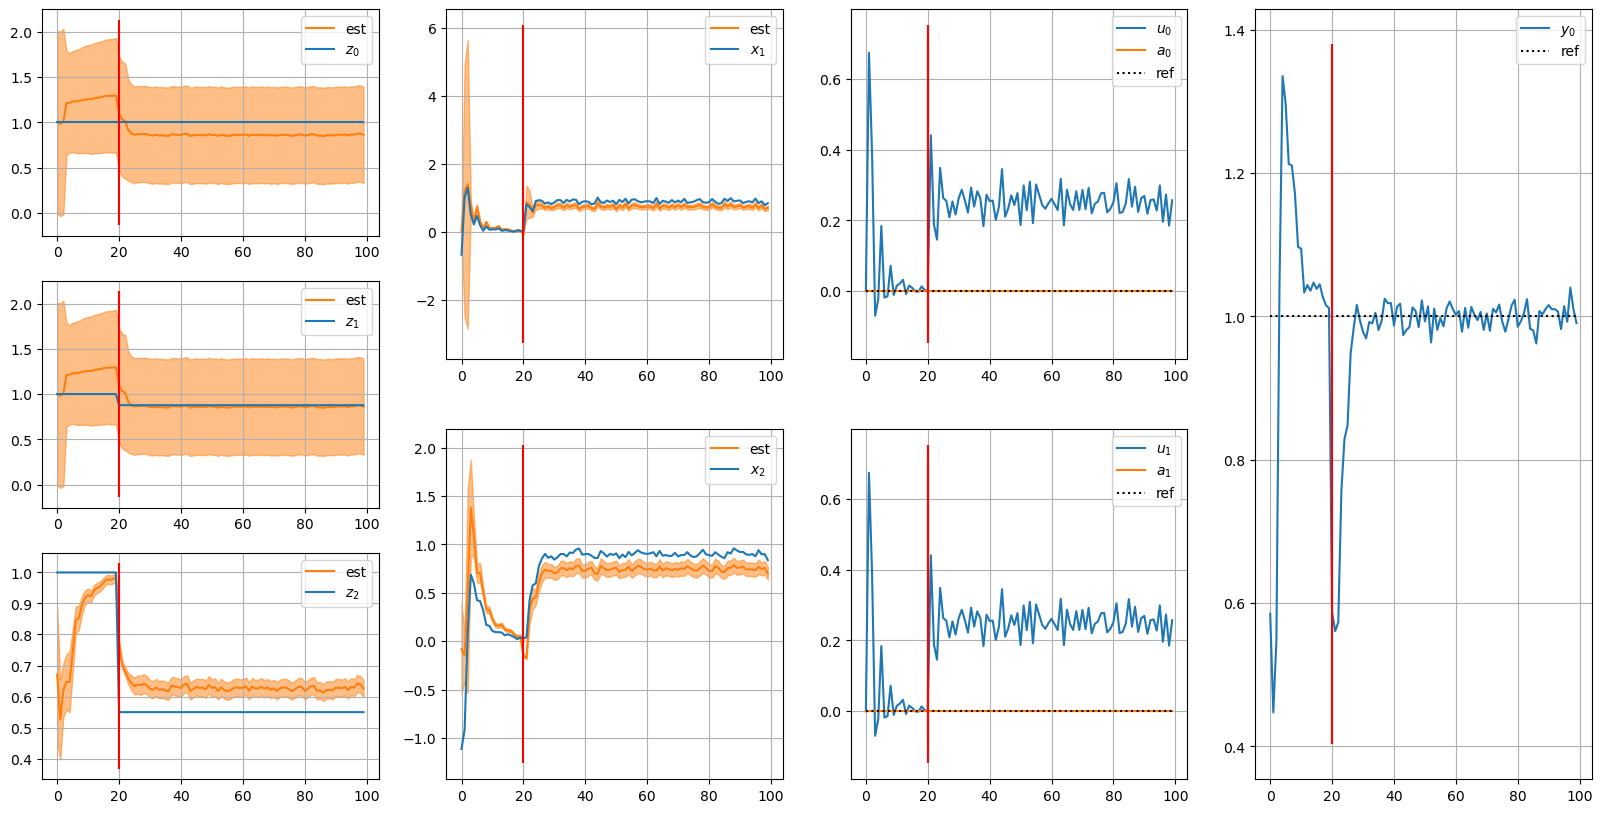

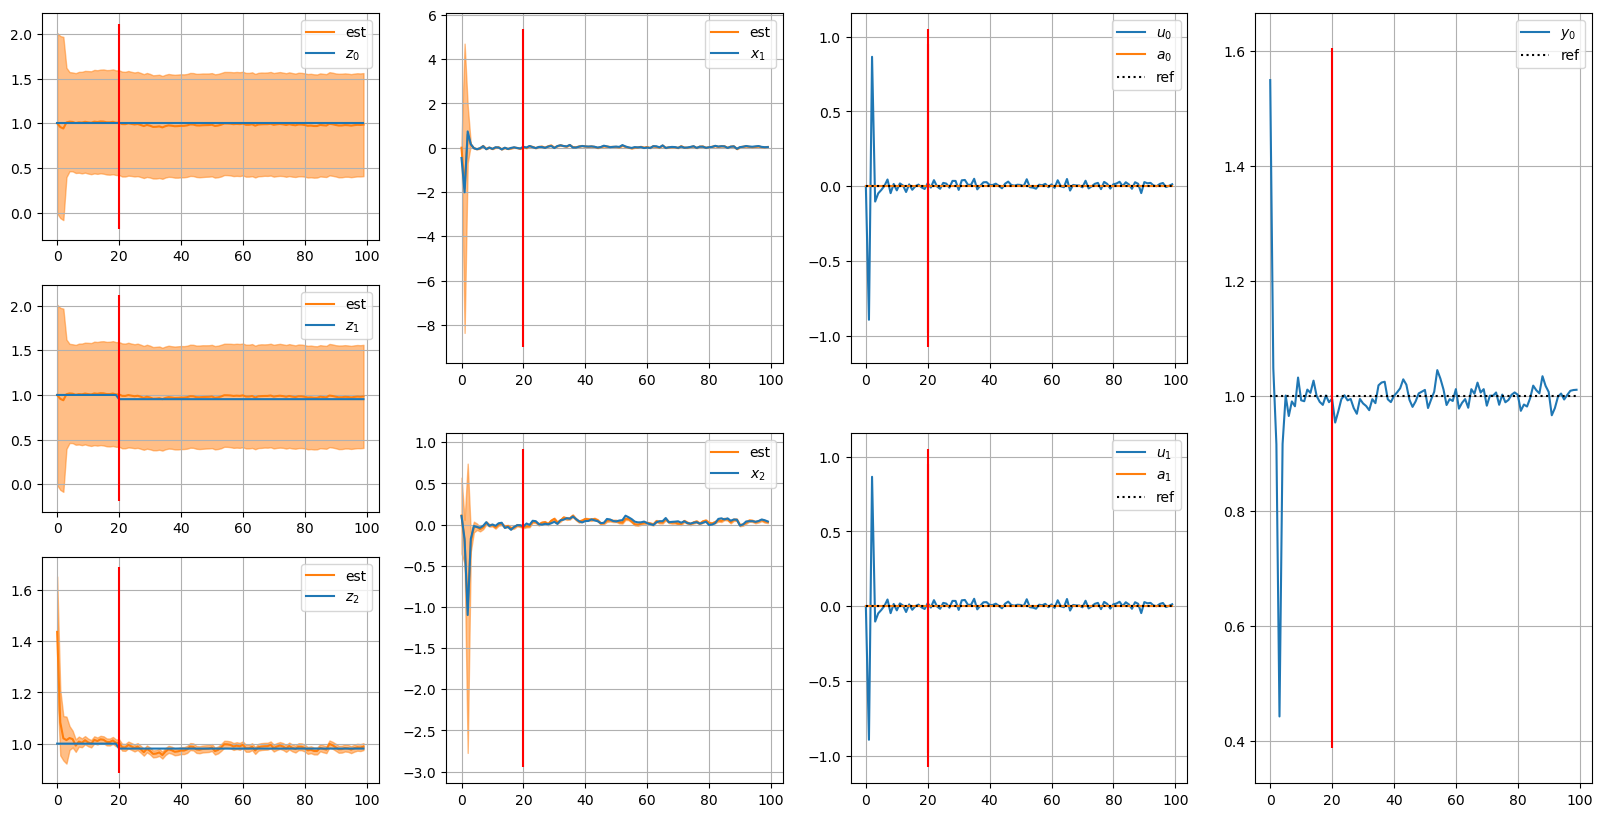

In [4]:
for seed in range(3):
    steps = sim.rollout(rng=jr.key(seed), use_aux=False)
    sim.plot(steps)

In [5]:
from ppo import optimize
sim, log_loss, log_rew, log_rew_std = optimize(sim)

AttributeError: 'Simulator' object has no attribute 'policy'

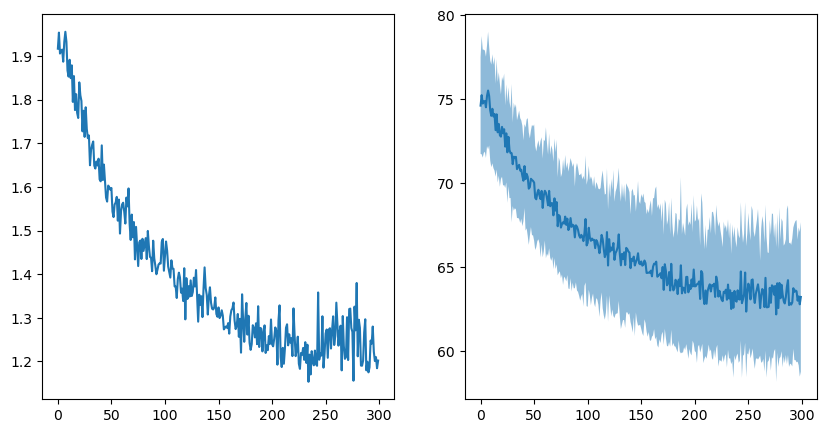

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(log_loss)
plt.subplot(122)
plt.plot(-log_rew)
plt.fill_between(range(len(log_rew)), -log_rew - log_rew_std, -log_rew + log_rew_std, alpha=0.5)

AVG cost: 0.9237471755545584


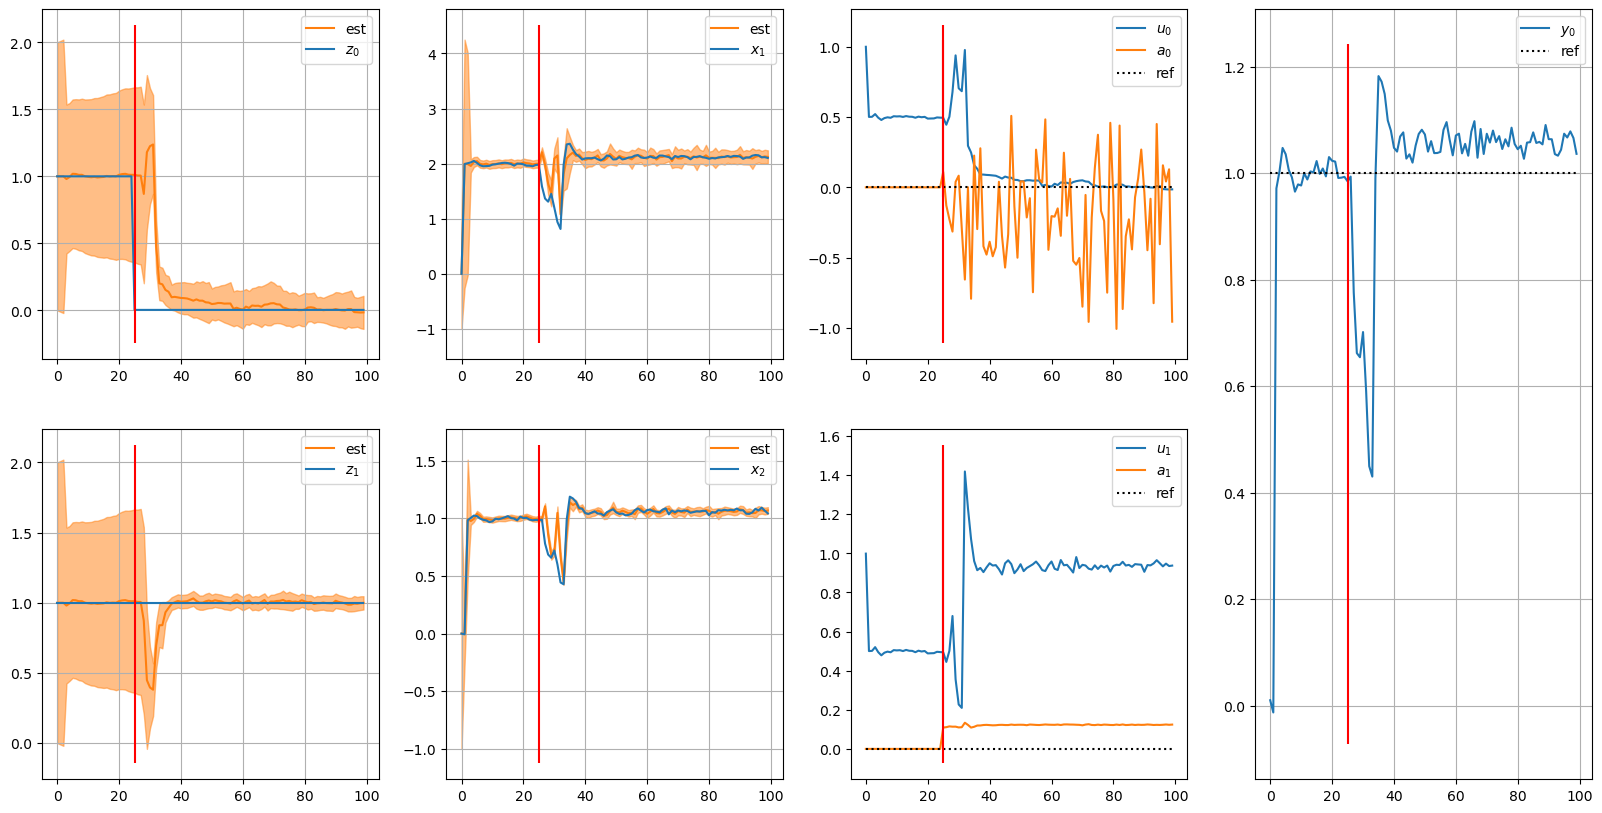

AVG cost: 0.8586384117578183


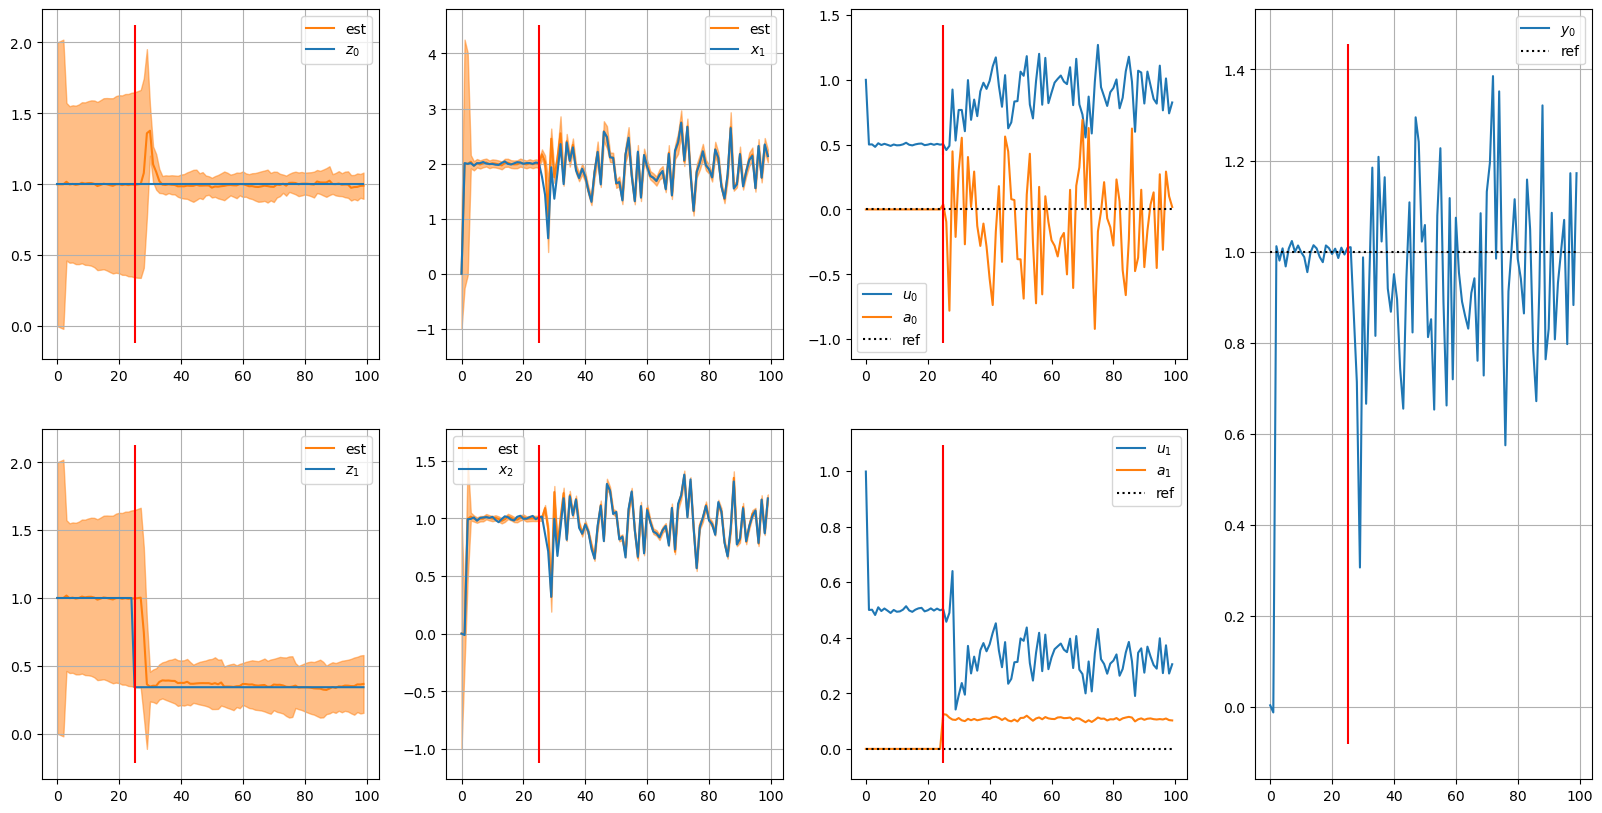

AVG cost: 0.7801965339497684


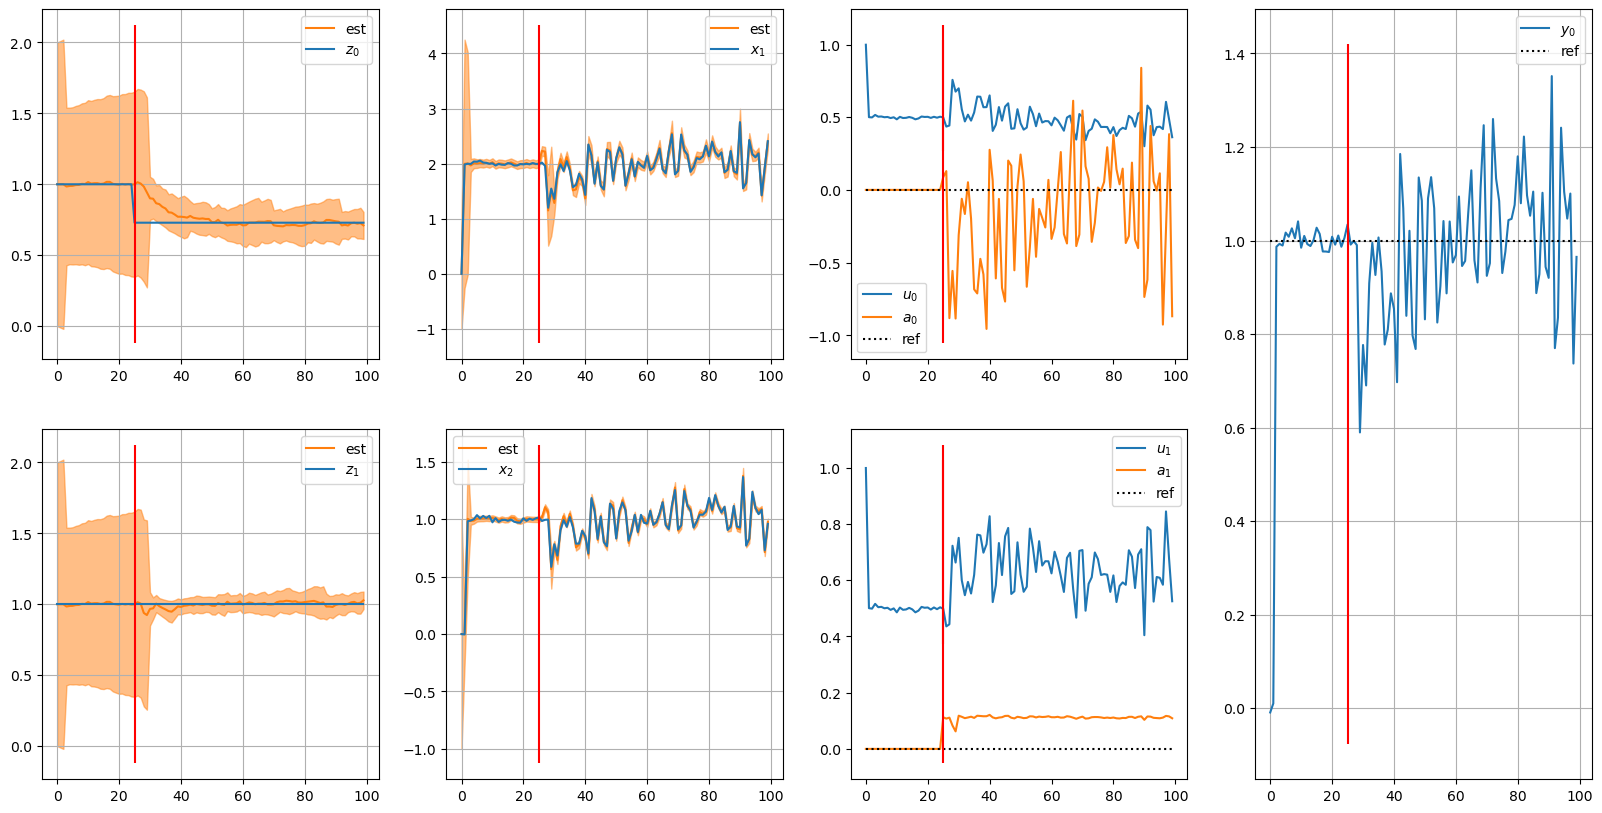

AVG cost: 0.854796474884001


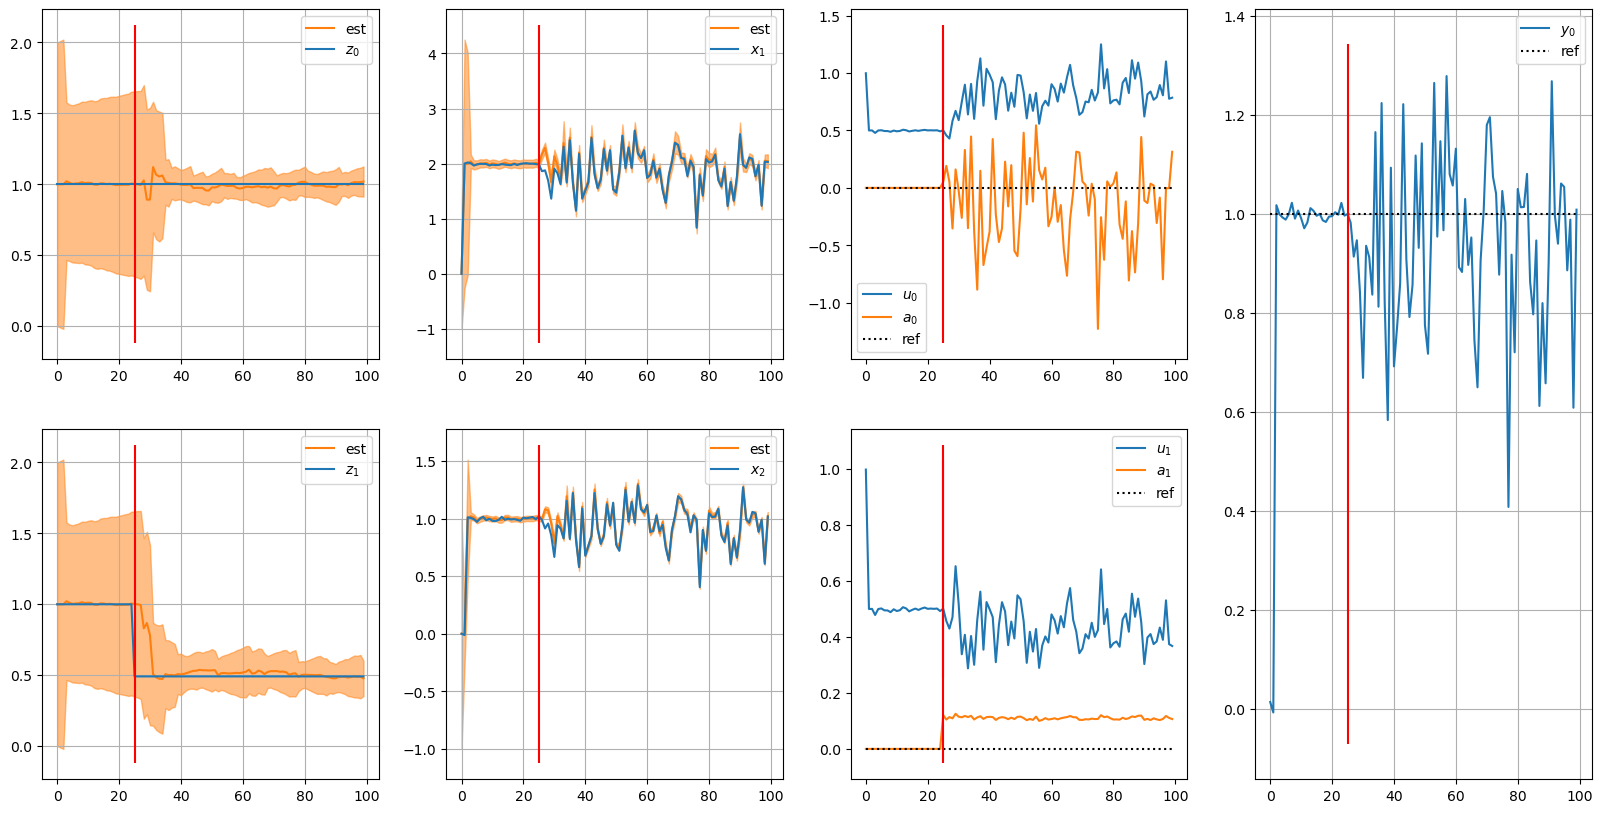

AVG cost: 0.8137451362300524


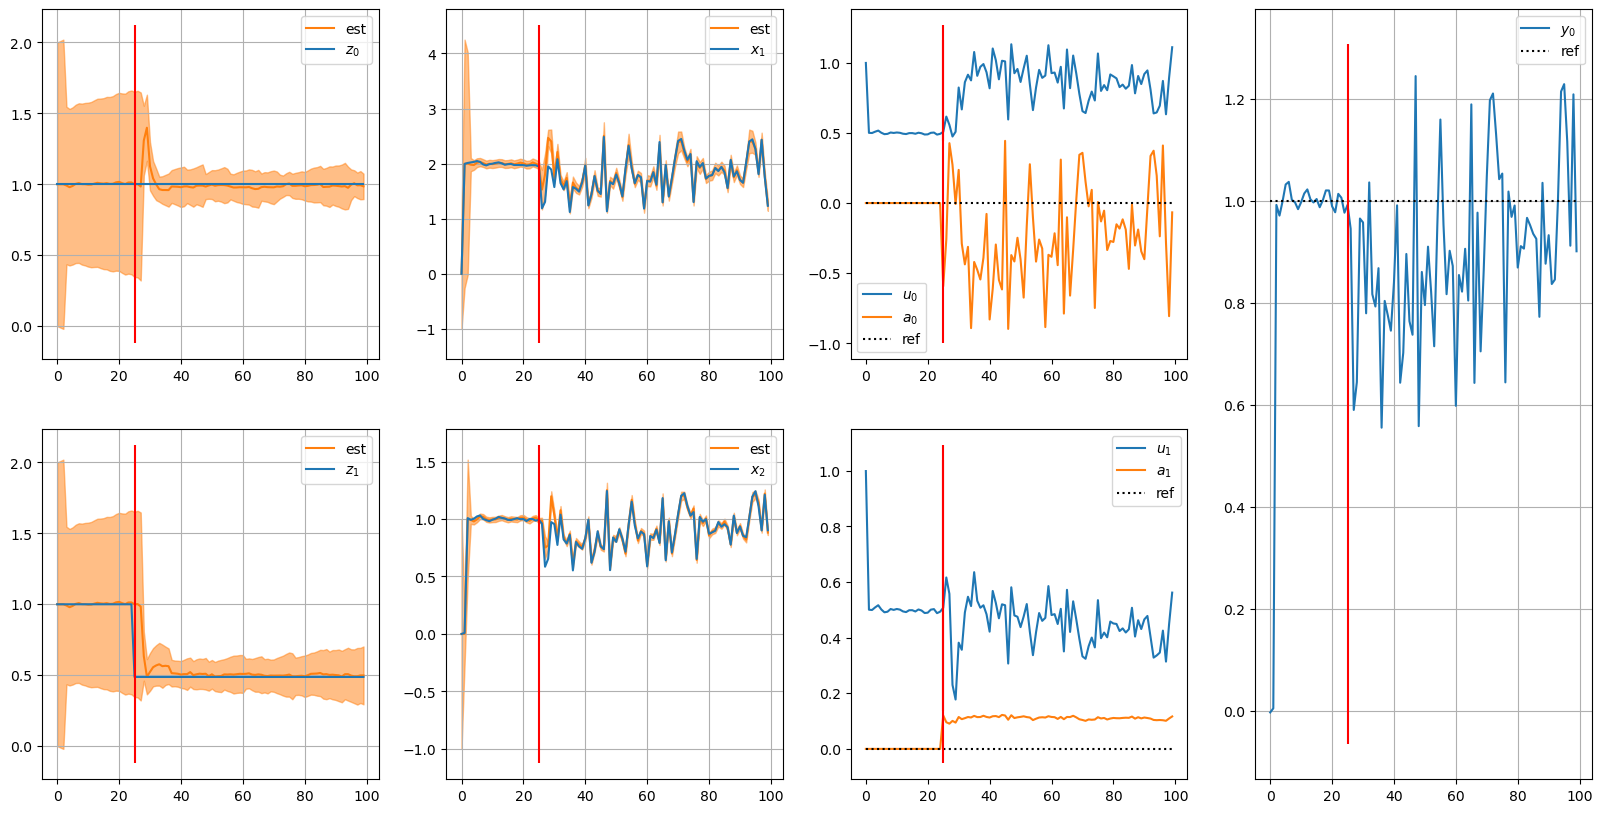

In [ ]:
for seed in range(5):
    _, out, rewards = sim.rollout(rng=jr.key(seed), explore=True)
    print("AVG cost:",-rewards.mean())
    sim.plot(out)